# RNN 삼성 주식가 예측

In [ ]:
!pip install --q ipython-autotime
%load_ext autotime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.9 MB/s eta 0:00:00
time: 426 µs (started: 2024-07-02 01:00:17 +00:00)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras

time: 9.07 s (started: 2024-07-02 01:00:17 +00:00)


## 1.데이터 준비

In [ ]:
samsung = pd.read_csv('/content/005930.KS.csv')
samsung.shape

(6140, 7)

time: 39.9 ms (started: 2024-07-02 01:03:36 +00:00)


In [ ]:
df = samsung.copy()
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-04,6000.0,6110.0,5660.0,6110.0,4449.709961,74195000
1,2000-01-05,5800.0,6060.0,5520.0,5580.0,4063.730957,74680000
2,2000-01-06,5750.0,5780.0,5580.0,5620.0,4092.860596,54390000
3,2000-01-07,5560.0,5670.0,5360.0,5540.0,4034.597656,40305000
4,2000-01-10,5600.0,5770.0,5580.0,5770.0,4202.099609,46880000


time: 54.5 ms (started: 2024-07-02 01:04:05 +00:00)


In [ ]:
df.columns = [col.replace(' ', '_').lower() for col in df.columns]
df.head()

,date,open,high,low,close,adj_close,volume
0,2000-01-04,6000.0,6110.0,5660.0,6110.0,4449.709961,74195000
1,2000-01-05,5800.0,6060.0,5520.0,5580.0,4063.730957,74680000
2,2000-01-06,5750.0,5780.0,5580.0,5620.0,4092.860596,54390000
3,2000-01-07,5560.0,5670.0,5360.0,5540.0,4034.597656,40305000
4,2000-01-10,5600.0,5770.0,5580.0,5770.0,4202.099609,46880000


time: 35 ms (started: 2024-07-02 01:05:54 +00:00)


## 2.데이터 확인

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6140 entries, 0 to 6139
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       6140 non-null   object 
 1   open       6140 non-null   float64
 2   high       6140 non-null   float64
 3   low        6140 non-null   float64
 4   close      6140 non-null   float64
 5   adj_close  6140 non-null   float64
 6   volume     6140 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 335.9+ KB
time: 24.9 ms (started: 2024-07-02 01:06:12 +00:00)


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
open,6140.0,2.848076e+04,2.269316e+04,2540.000000,1.072000e+04,2.125000e+04,4.575000e+04,90300.0
high,6140.0,2.875581e+04,2.286959e+04,2760.000000,1.090000e+04,2.149000e+04,4.618500e+04,96800.0
low,6140.0,2.819435e+04,2.249832e+04,2420.000000,1.057500e+04,2.100000e+04,4.525000e+04,89500.0
close,6140.0,2.847089e+04,2.267169e+04,2730.000000,1.074000e+04,2.126000e+04,4.570000e+04,91000.0
adj_close,6140.0,2.462311e+04,2.216919e+04,1988.169434,7.915908e+03,1.644601e+04,3.910023e+04,85300.0
volume,6140.0,2.116503e+07,1.504671e+07,0.000000,1.169729e+07,1.715452e+07,2.617382e+07,164215000.0


time: 72.2 ms (started: 2024-07-02 01:07:14 +00:00)


In [ ]:
df[df['volume'] == 0]

,date,open,high,low,close,adj_close,volume
23,2000-02-04,5130.0,5130.0,5130.0,5130.0,3736.009521,0
41,2000-03-01,5120.0,5120.0,5120.0,5120.0,3728.726563,0
66,2000-04-05,6800.0,6800.0,6800.0,6800.0,4952.213867,0
72,2000-04-13,6910.0,6910.0,6910.0,6910.0,5032.322754,0
84,2000-05-01,6000.0,6000.0,6000.0,6000.0,4369.600586,0
...,...,...,...,...,...,...,...
5564,2022-02-28,71900.0,71900.0,71900.0,71900.0,68423.640625,0
5567,2022-03-04,72900.0,72900.0,72900.0,72900.0,69375.312500,0
5570,2022-03-10,69500.0,69500.0,69500.0,69500.0,66139.695313,0
5573,2022-03-15,70200.0,70200.0,70200.0,70200.0,66805.835938,0


time: 29.3 ms (started: 2024-07-02 01:08:29 +00:00)


In [ ]:
df.loc[df['volume'] == 0, 'volume'] = np.nan
df.isna().sum()

date           0
open           0
high           0
low            0
close          0
adj_close      0
volume       127
dtype: int64

time: 15.1 ms (started: 2024-07-02 01:10:34 +00:00)


In [ ]:
df = df.dropna()
df.isna().sum()

date         0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

time: 12 ms (started: 2024-07-02 01:11:04 +00:00)


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6013 entries, 0 to 6139
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       6013 non-null   datetime64[ns]
 1   open       6013 non-null   float64       
 2   high       6013 non-null   float64       
 3   low        6013 non-null   float64       
 4   close      6013 non-null   float64       
 5   adj_close  6013 non-null   float64       
 6   volume     6013 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 375.8 KB
time: 15.3 ms (started: 2024-07-02 01:12:41 +00:00)


In [ ]:
df.head()

,date,open,high,low,close,adj_close,volume
0,2000-01-04,6000.0,6110.0,5660.0,6110.0,4449.709961,74195000.0
1,2000-01-05,5800.0,6060.0,5520.0,5580.0,4063.730957,74680000.0
2,2000-01-06,5750.0,5780.0,5580.0,5620.0,4092.860596,54390000.0
3,2000-01-07,5560.0,5670.0,5360.0,5540.0,4034.597656,40305000.0
4,2000-01-10,5600.0,5770.0,5580.0,5770.0,4202.099609,46880000.0


time: 51.8 ms (started: 2024-07-02 01:13:05 +00:00)


In [ ]:
df = df.set_index('date')
df.head()

,open,high,low,close,adj_close,volume
date,,,,,,
2000-01-04,6000.0,6110.0,5660.0,6110.0,4449.709961,74195000.0
2000-01-05,5800.0,6060.0,5520.0,5580.0,4063.730957,74680000.0
2000-01-06,5750.0,5780.0,5580.0,5620.0,4092.860596,54390000.0
2000-01-07,5560.0,5670.0,5360.0,5540.0,4034.597656,40305000.0
2000-01-10,5600.0,5770.0,5580.0,5770.0,4202.099609,46880000.0


time: 35.8 ms (started: 2024-07-02 01:13:52 +00:00)


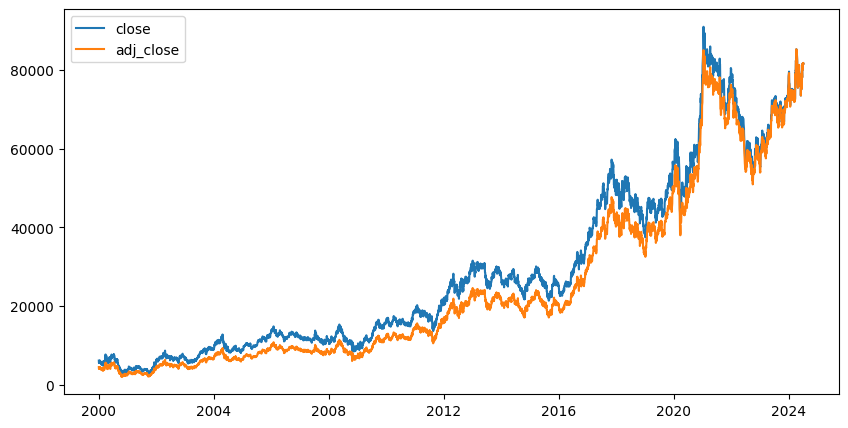

time: 441 ms (started: 2024-07-02 01:15:43 +00:00)


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['close'], label='close')
plt.plot(df.index, df['adj_close'], label='adj_close')
plt.legend()
plt.show()

In [ ]:
df['ma3'] = np.around(df['close'].rolling(window=3).mean(),0)
df.head()

,open,high,low,close,adj_close,volume,ma3
date,,,,,,,
2000-01-04,6000.0,6110.0,5660.0,6110.0,4449.709961,74195000.0,NaN
2000-01-05,5800.0,6060.0,5520.0,5580.0,4063.730957,74680000.0,NaN
2000-01-06,5750.0,5780.0,5580.0,5620.0,4092.860596,54390000.0,5770.0
2000-01-07,5560.0,5670.0,5360.0,5540.0,4034.597656,40305000.0,5580.0
2000-01-10,5600.0,5770.0,5580.0,5770.0,4202.099609,46880000.0,5643.0


time: 77.8 ms (started: 2024-07-02 01:19:08 +00:00)


In [ ]:
df['ma5'] = np.around(df['close'].rolling(window=5).mean(),0)
df.head()

,open,high,low,close,adj_close,volume,ma3,ma5
date,,,,,,,,
2000-01-04,6000.0,6110.0,5660.0,6110.0,4449.709961,74195000.0,NaN,NaN
2000-01-05,5800.0,6060.0,5520.0,5580.0,4063.730957,74680000.0,NaN,NaN
2000-01-06,5750.0,5780.0,5580.0,5620.0,4092.860596,54390000.0,5770.0,NaN
2000-01-07,5560.0,5670.0,5360.0,5540.0,4034.597656,40305000.0,5580.0,NaN
2000-01-10,5600.0,5770.0,5580.0,5770.0,4202.099609,46880000.0,5643.0,5724.0


time: 42.4 ms (started: 2024-07-02 01:19:46 +00:00)


In [ ]:
df['mid'] = (df['low'] + df['high'])/2
df.head()

,open,high,low,close,adj_close,volume,ma3,ma5,mid
date,,,,,,,,,
2000-01-04,6000.0,6110.0,5660.0,6110.0,4449.709961,74195000.0,NaN,NaN,5885.0
2000-01-05,5800.0,6060.0,5520.0,5580.0,4063.730957,74680000.0,NaN,NaN,5790.0
2000-01-06,5750.0,5780.0,5580.0,5620.0,4092.860596,54390000.0,5770.0,NaN,5680.0
2000-01-07,5560.0,5670.0,5360.0,5540.0,4034.597656,40305000.0,5580.0,NaN,5515.0
2000-01-10,5600.0,5770.0,5580.0,5770.0,4202.099609,46880000.0,5643.0,5724.0,5675.0


time: 122 ms (started: 2024-07-02 01:20:51 +00:00)


In [ ]:
df = df.dropna()
df.isna().sum()

open         0
high         0
low          0
close        0
adj_close    0
volume       0
ma3          0
ma5          0
mid          0
dtype: int64

time: 14.4 ms (started: 2024-07-02 01:21:31 +00:00)


## 3.학습, 테스트 데이터 분리

In [ ]:
df.shape

(6009, 9)

time: 12.9 ms (started: 2024-07-02 01:22:56 +00:00)


In [ ]:
idx = int(df.shape[0]*0.8)
idx

4807

time: 12.1 ms (started: 2024-07-02 01:24:10 +00:00)


In [ ]:
train = df.iloc[:idx, :]
test = df.iloc[idx: , :]

train.shape, test.shape

((4807, 9), (1202, 9))

time: 14.5 ms (started: 2024-07-02 01:24:57 +00:00)


### X, y 분리

In [ ]:
train.head()

,open,high,low,close,adj_close,volume,ma3,ma5,mid
date,,,,,,,,,
2000-01-10,5600.0,5770.0,5580.0,5770.0,4202.099609,46880000.0,5643.0,5724.0,5675.0
2000-01-11,5820.0,6100.0,5770.0,5770.0,4202.099609,59745000.0,5693.0,5656.0,5935.0
2000-01-12,5610.0,5740.0,5600.0,5720.0,4165.686035,29220000.0,5753.0,5684.0,5670.0
2000-01-13,5600.0,5740.0,5560.0,5710.0,4158.402344,41190000.0,5733.0,5702.0,5650.0
2000-01-14,5720.0,5880.0,5680.0,5830.0,4245.794434,49375000.0,5753.0,5760.0,5780.0


time: 91.2 ms (started: 2024-07-02 01:25:33 +00:00)


In [ ]:
X_train = train.drop(['close', 'adj_close'], axis=1)
y_train = train['close']

X_train.shape, y_train.shape

((4807, 7), (4807,))

time: 18 ms (started: 2024-07-02 01:27:35 +00:00)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()
X_train_s = ms.fit_transform(X_train)

time: 872 ms (started: 2024-07-02 01:29:20 +00:00)


In [ ]:
y_train = y_train.to_numpy()
y_train

array([ 5770.,  5770.,  5720., ..., 47200., 47300., 46400.])

time: 18.1 ms (started: 2024-07-02 01:29:58 +00:00)


### 타임스텝 데이터형태로 변형

In [ ]:
def make_sequence_dataset(X, y, window_size):
    feature_list = []
    label_list = []

    for i in range(len(X) - window_size):
        feature_list.append(X[i:i+window_size])
        label_list.append(y[i+window_size])

    return np.array(feature_list), np.array(label_list)

time: 1.3 ms (started: 2024-07-02 01:37:03 +00:00)


In [ ]:
X_train_w, y_train_w = make_sequence_dataset(X_train_s, y_train, 20)

X_train_w.shape, y_train_w.shape

((4787, 20, 7), (4787,))

time: 46.3 ms (started: 2024-07-02 01:38:31 +00:00)


## 4.모델

In [ ]:
X_train_w.shape

(4787, 20, 7)

time: 13.8 ms (started: 2024-07-02 01:41:54 +00:00)


In [ ]:
from keras import layers

model = keras.Sequential()
model.add(layers.LSTM(32,  activation='relu', input_shape=(20, 7)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1))

time: 322 ms (started: 2024-07-02 02:14:17 +00:00)


In [ ]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 32)                5120      
                                                                 
 dense_4 (Dense)             (None, 16)                528       
                                                                 
 dense_5 (Dense)             (None, 1)                 17        
                                                                 
Total params: 5665 (22.13 KB)
Trainable params: 5665 (22.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
time: 29.3 ms (started: 2024-07-02 02:14:18 +00:00)


In [ ]:
model.compile(
    loss = 'mse',
    optimizer  = 'adam',
    metrics=['mse', 'mae']
)

time: 35 ms (started: 2024-07-02 02:14:18 +00:00)


In [ ]:
EPOCHS = 20
BATCH_SIZE = 16

history = model.fit(X_train_w, y_train_w,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_split=0.2)

Epoch 1/20
240/240 [==============================] - 7s 18ms/step - loss: 266193680.0000 - mse: 266193680.0000 - mae: 14359.7100 - val_loss: 1658790912.0000 - val_mse: 1658790912.0000 - val_mae: 39541.0859
Epoch 2/20
240/240 [==============================] - 3s 11ms/step - loss: 263765888.0000 - mse: 263765888.0000 - mae: 14274.8262 - val_loss: 1649780096.0000 - val_mse: 1649780096.0000 - val_mae: 39426.9883
Epoch 3/20
240/240 [==============================] - 3s 11ms/step - loss: 259695328.0000 - mse: 259695328.0000 - mae: 14132.0342 - val_loss: 1636208768.0000 - val_mse: 1636208768.0000 - val_mae: 39254.4883
Epoch 4/20
240/240 [==============================] - 3s 11ms/step - loss: 254065120.0000 - mse: 254065120.0000 - mae: 13931.3125 - val_loss: 1618351360.0000 - val_mse: 1618351360.0000 - val_mae: 39026.3711
Epoch 5/20
240/240 [==============================] - 3s 14ms/step - loss: 247082816.0000 - mse: 247082816.0000 - mae: 13677.2324 - val_loss: 1596753280.0000 - val_mse: 159

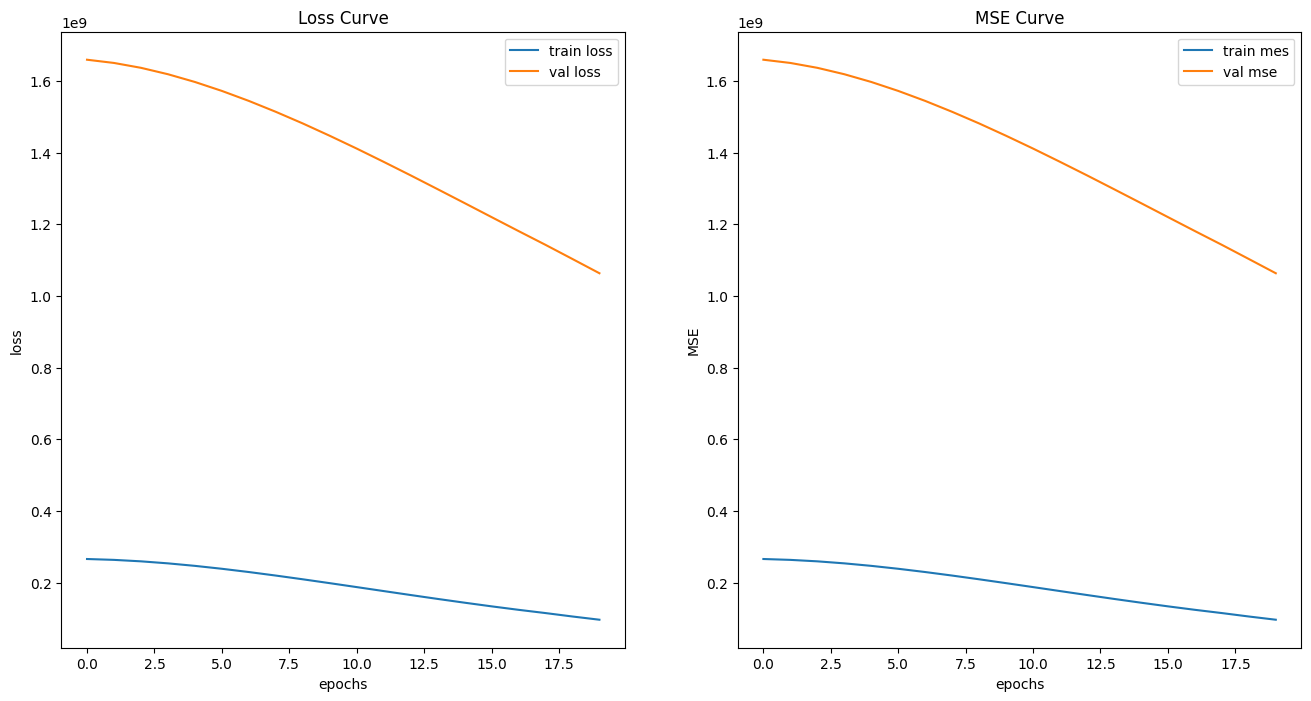

time: 575 ms (started: 2024-07-02 02:15:42 +00:00)


In [ ]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.plot(hist['epoch'], hist['loss'], label='train loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='val loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.xlabel('epochs')
    plt.ylabel('MSE')
    plt.plot(hist['epoch'], hist['mse'], label='train mes')
    plt.plot(hist['epoch'], hist['val_mse'], label='val mse')
    plt.title('MSE Curve')
    plt.legend()
    plt.show()

plot_history(history)

## 평가

In [ ]:
X_test = test.drop(['close', 'adj_close'], axis=1)
y_test = test['close']

X_test.shape, y_test.shape

((1202, 7), (1202,))

time: 6.45 ms (started: 2024-07-02 02:15:43 +00:00)


In [ ]:
X_test_s = ms.transform(X_test)
y_test = y_test.to_numpy()

X_test_s.shape, y_test.shape

((1202, 7), (1202,))

time: 8.37 ms (started: 2024-07-02 02:15:43 +00:00)


In [ ]:
X_test_w, y_test_w = make_sequence_dataset(X_test_s, y_test, 20)

X_test_w.shape, y_test_w.shape

((1182, 20, 7), (1182,))

time: 8.3 ms (started: 2024-07-02 02:15:43 +00:00)


In [ ]:
y_pred = model.predict(X_test_w)
y_pred

37/37 [==============================] - 1s 5ms/step


array([[8484.65 ],
       [8484.65 ],
       [8484.65 ],
       ...,
       [8484.463],
       [8484.453],
       [8484.445]], dtype=float32)

time: 764 ms (started: 2024-07-02 02:15:43 +00:00)


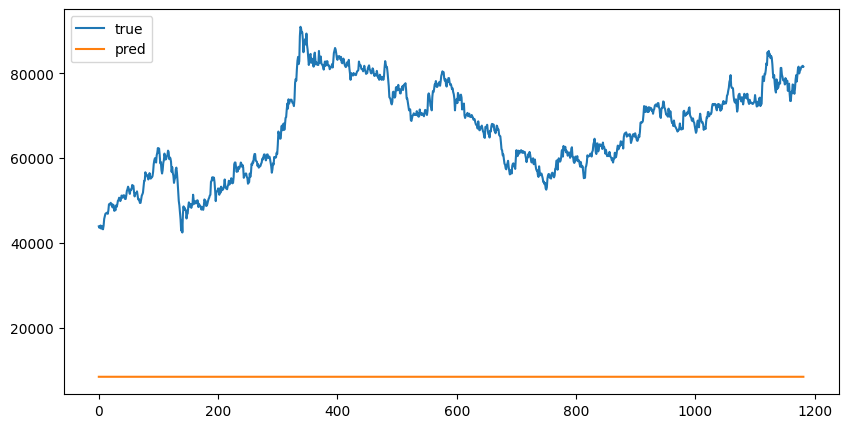

time: 242 ms (started: 2024-07-02 02:15:44 +00:00)


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test_w, label='true')
plt.plot(y_pred.flatten(), label='pred')
plt.legend()
plt.show()

## 입력이 2개인 모델

In [ ]:
# 첫번째 입력

input1 = layers.Input(shape=(20, 7))
x = layers.LSTM(64, activation='relu')(input1)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(132, activation='relu')(x)
output1 = layers.Dense(32, activation='relu')(x)

time: 258 ms (started: 2024-07-02 02:24:26 +00:00)


In [ ]:
# 두번째 입력

input2 = layers.Input(shape=(20, 7))
x = layers.LSTM(64, activation='relu')(input2)
output2 = layers.Dense(32, activation='relu')(x)


time: 125 ms (started: 2024-07-02 02:24:29 +00:00)


In [ ]:
merge = layers.Concatenate()([output1, output2])
output3 = layers.Dense(1)(merge)

model = keras.Model(inputs=[input1, input2], outputs=output3)

time: 62.3 ms (started: 2024-07-02 02:24:39 +00:00)


In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 20, 7)]              0         []                            
                                                                                                  
 lstm_6 (LSTM)               (None, 64)                   18432     ['input_3[0][0]']             
                                                                                                  
 dense_10 (Dense)            (None, 32)                   2080      ['lstm_6[0][0]']              
                                                                                                  
 input_4 (InputLayer)        [(None, 20, 7)]              0         []                            
                                                                                              

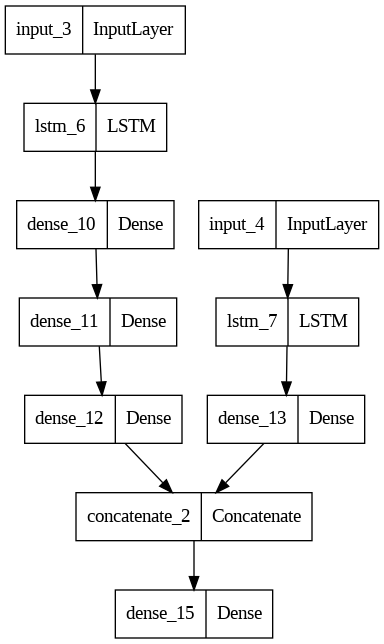

time: 441 ms (started: 2024-07-02 02:25:13 +00:00)


In [ ]:
keras.utils.plot_model(model)

In [ ]:
model.compile(loss='mse', optimizer='adam', metrics=['mse'])

time: 17.1 ms (started: 2024-07-02 02:29:56 +00:00)


In [ ]:
model.fit(
    [X_train_w, X_train_w], y_train_w,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2
)

Epoch 1/20
240/240 [==============================] - 10s 21ms/step - loss: 52946316.0000 - mse: 52946316.0000 - val_loss: 137272848.0000 - val_mse: 137272848.0000
Epoch 2/20
240/240 [==============================] - 5s 21ms/step - loss: 2917061.0000 - mse: 2917061.0000 - val_loss: 98538680.0000 - val_mse: 98538680.0000
Epoch 3/20
240/240 [==============================] - 5s 22ms/step - loss: 1711089.8750 - mse: 1711089.8750 - val_loss: 25545386.0000 - val_mse: 25545386.0000
Epoch 4/20
240/240 [==============================] - 5s 19ms/step - loss: 1859397.6250 - mse: 1859397.6250 - val_loss: 26876236.0000 - val_mse: 26876236.0000
Epoch 5/20
240/240 [==============================] - 6s 24ms/step - loss: 2306334.5000 - mse: 2306334.5000 - val_loss: 12192959.0000 - val_mse: 12192959.0000
Epoch 6/20
240/240 [==============================] - 5s 19ms/step - loss: 1369759.5000 - mse: 1369759.5000 - val_loss: 10869205.0000 - val_mse: 10869205.0000
Epoch 7/20
240/240 [=====================

time: 2min 26s (started: 2024-07-02 02:29:58 +00:00)


In [ ]:
y_pred = model.predict([X_test_w, X_test_w])

37/37 [==============================] - 1s 7ms/step
time: 748 ms (started: 2024-07-02 02:32:26 +00:00)


In [ ]:
y_pred

array([[43004.02 ],
       [42788.965],
       [42533.355],
       ...,
       [63046.19 ],
       [62943.47 ],
       [62997.457]], dtype=float32)

time: 12.6 ms (started: 2024-07-02 02:32:38 +00:00)


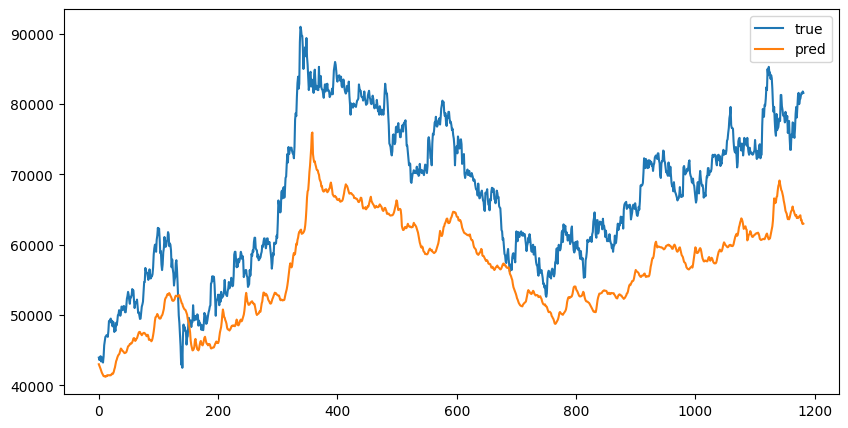

time: 395 ms (started: 2024-07-02 02:32:55 +00:00)


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test_w, label='true')
plt.plot(y_pred.flatten(), label='pred')
plt.legend()
plt.show()